In [5]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
# Notebooks run from the notebooks folder, so the src folder is added to the path.
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, rasterio, matplotlib.pyplot as plt
from tqdm import tqdm
import config

In [6]:
import json, joblib
from prepare import load_chips
from metrics import calculate_ndvi
from features import build_features

model = joblib.load(config.MODEL_FILE)
threshold = json.loads(config.NDVI_THRESHOLD_FILE.read_text())["threshold"]
shape = (config.STUDY_AREA.height, config.STUDY_AREA.width)
maps = {config.RF_PREDICTION_FILE: np.zeros(shape, "uint8"), config.NDVI_PREDICTION_FILE: np.zeros(shape, "uint8")}

for chip in tqdm(load_chips()):
    cells = np.s_[chip["row"]:chip["row"] + config.CHIP_SIZE, chip["col"]:chip["col"] + config.CHIP_SIZE]
    # Features must match training exactly, as a mismatch produces no error.
    maps[config.RF_PREDICTION_FILE][cells] = model.predict(build_features(chip["img"])).reshape(config.CHIP_SIZE, config.CHIP_SIZE)
    maps[config.NDVI_PREDICTION_FILE][cells] = calculate_ndvi(chip["img"]) > threshold

# The aligned label profile is reused so both outputs are correctly georeferenced.
with rasterio.open(config.LABELS_FILE) as labels:
    profile = labels.profile
for path, array in maps.items():
    with rasterio.open(path, "w", **profile) as output:
        output.write(array, 1)
    print(f"{path.name}: canopy fraction {array.mean():.3f}")

100%|██████████| 1911/1911 [04:45<00:00,  6.69it/s]


rf_prediction.tif: canopy fraction 0.244
ndvi_prediction.tif: canopy fraction 0.260


In [7]:
import geopandas as gpd
from rasterstats import zonal_stats
from shapely.geometry import box

with rasterio.open(config.RF_PREDICTION_FILE) as prediction:
    outline, crs = box(*prediction.bounds), prediction.crs
# zonal_stats does not reproject, so the neighborhoods are converted to the raster CRS first.
neighborhoods = gpd.read_file(config.NTA_FILE).to_crs(crs)
neighborhoods = neighborhoods[neighborhoods.intersects(outline)].copy()
NAME = "ntaname" if "ntaname" in neighborhoods.columns else "NTAName"

# The mean of a binary raster within a polygon gives the canopy fraction.
for column, path in [("reference", config.LABELS_FILE), ("rf", config.RF_PREDICTION_FILE), ("ndvi", config.NDVI_PREDICTION_FILE)]:
    neighborhoods[column] = [np.nan if s["mean"] is None else s["mean"] * 100
                             for s in zonal_stats(neighborhoods, str(path), stats=["mean"], nodata=255)]
neighborhoods["error_rf"] = neighborhoods["rf"] - neighborhoods["reference"]
neighborhoods["error_ndvi"] = neighborhoods["ndvi"] - neighborhoods["reference"]
# Partially covered neighborhoods are underestimated, so they are flagged and excluded from statistics.
neighborhoods["fully_inside"] = neighborhoods.within(outline)
neighborhoods.to_file(config.NEIGHBORHOOD_FILE, driver="GeoJSON")
print(f"{len(neighborhoods)} neighborhoods intersect the study area; {neighborhoods['fully_inside'].sum()} are fully inside")

32 neighborhoods intersect the study area; 9 are fully inside


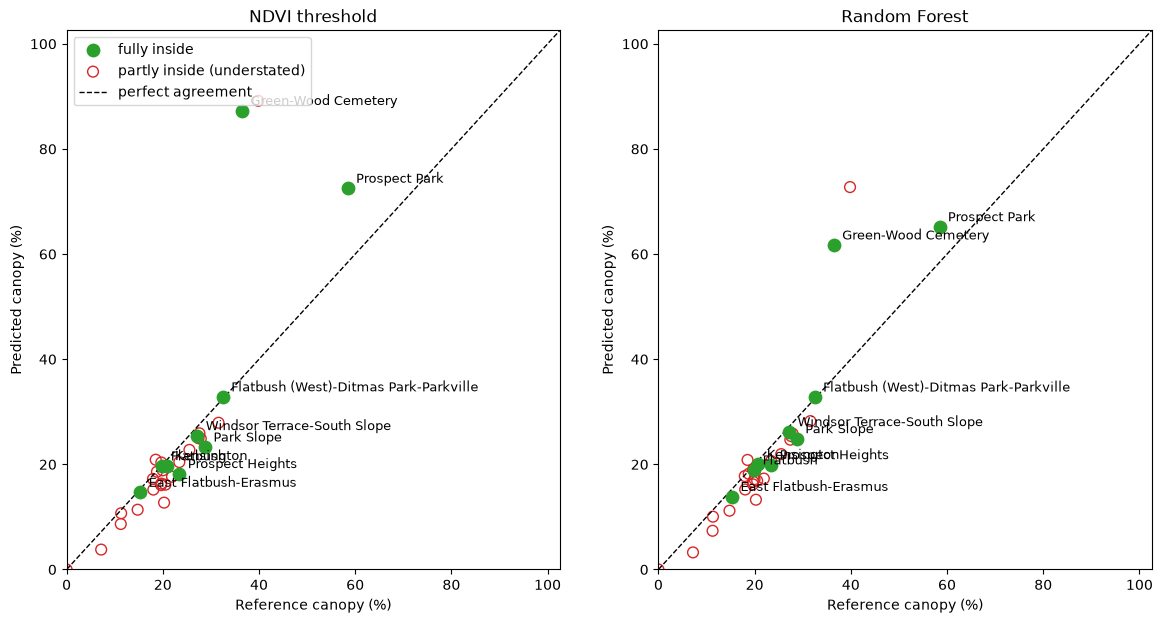

Based on 9 fully covered neighborhoods
  NDVI           average error +5.6 pp | average size 8.8 pp
  Random Forest  average error +2.3 pp | average size 4.9 pp


In [8]:
full, partial = neighborhoods[neighborhoods["fully_inside"]], neighborhoods[~neighborhoods["fully_inside"]]
limit = neighborhoods[["reference", "rf", "ndvi"]].max().max() * 1.15
figure, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, column, title in zip(axes, ["ndvi", "rf"], ["NDVI threshold", "Random Forest"]):
    ax.scatter(full["reference"], full[column], s=80, color="tab:green", label="fully inside", zorder=3)
    ax.scatter(partial["reference"], partial[column], s=60, facecolors="none", edgecolors="tab:red", label="partly inside (understated)")
    # Only fully covered neighborhoods are labeled, as only they are reported.
    for _, n in full.iterrows():
        ax.annotate(n[NAME], (n["reference"], n[column]), xytext=(6, 4), textcoords="offset points", fontsize=9)
    ax.plot([0, limit], [0, limit], "k--", linewidth=1, label="perfect agreement")
    ax.set(xlim=(0, limit), ylim=(0, limit), xlabel="Reference canopy (%)", ylabel="Predicted canopy (%)", title=title)
axes[0].legend(loc="upper left")
plt.savefig(config.FIGURES / "04_neighborhood_scatter.png", dpi=120, bbox_inches="tight"); plt.show()

# Average error keeps its sign and shows bias; average size of error ignores direction.
print(f"Based on {len(full)} fully covered neighborhoods")
for label, column in [("NDVI", "error_ndvi"), ("Random Forest", "error_rf")]:
    print(f"  {label:14s} average error {full[column].mean():+.1f} pp | average size {full[column].abs().mean():.1f} pp")

Out of 32 neighborhoods, only 9 were completely in the study area, with the others being partially within the image tile. The average error shows more over-prediction than under-prediction in both models. However, the over-prediction is largely elevated due to two largely vegetation-heavy areas. Overall, both the average error and average error size are lower for the Random Forest model over the NDVI threshold model.

In [14]:
import folium
from branca.element import MacroElement, Template

web = gpd.read_file(config.NEIGHBORHOOD_FILE).to_crs(4326)
# Only required columns are kept, as folium cannot serialize the date fields.
web = web[[NAME, "rf", "reference", "error_rf", "fully_inside", "geometry"]].round(1)
web["coverage"] = np.where(web["fully_inside"], "Fully inside study area", "Partly inside, value understated")
# The study area outline from Cell 3, reprojected for the web map.
study_area = gpd.GeoSeries([outline], crs=crs).to_crs(4326)
center = web.geometry.union_all().centroid
canopy_map = folium.Map([center.y, center.x], zoom_start=13, tiles=None)
# Free basemaps that require no API key.
basemaps = {
    "NYC basemap": ("https://maps.nyc.gov/xyz/1.0.0/carto/basemap/{z}/{x}/{y}.jpg", "NYC Office of Technology and Innovation"),
    "OpenStreetMap": ("https://tile.openstreetmap.org/{z}/{x}/{y}.png", "&copy; OpenStreetMap contributors"),
    "USGS imagery": ("https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}", "USGS The National Map"),
}
for index, (name, (url, attribution)) in enumerate(basemaps.items()):
    # Only the first basemap is displayed when the map opens.
    folium.TileLayer(tiles=url, attr=attribution, name=name, show=index == 0).add_to(canopy_map)


def make_tooltip():
    """Create the neighborhood tooltip; each layer requires its own copy."""
    return folium.GeoJsonTooltip([NAME, "rf", "reference", "error_rf", "coverage"], localize=True,
                                 aliases=["Neighborhood", "Predicted %", "Reference %", "Error (pp)", "Coverage"])


# A lower opacity lets the vegetation in the aerial imagery show through the fill.
fill = folium.Choropleth(web, data=web, columns=[NAME, "rf"], key_on=f"feature.properties.{NAME}", fill_color="YlGn",
                         fill_opacity=0.45, line_weight=1.5, line_color="#444444", legend_name="Predicted tree canopy (%)",
                         name="Predicted canopy fill")
fill.add_to(canopy_map)
# The tooltip is also attached to the fill, so it works whichever layer is drawn on top.
make_tooltip().add_to(fill.geojson)
boundaries = folium.GeoJson(web, name="Boundaries", style_function=lambda f: {"fillOpacity": 0, "weight": 1.5, "color": "#444444"},
                            tooltip=make_tooltip()).add_to(canopy_map)
# The study area outline; neighborhoods crossing it are only partly covered.
folium.GeoJson(study_area, name="Study area", style_function=lambda f: {"fill": False, "color": "#cc0000", "weight": 2.5}).add_to(canopy_map)

# Browser script that turns the outlines white over aerial imagery and gray over the street basemaps.
script = """
{% macro script(this, kwargs) %}
MAP.on("baselayerchange", function (event) {
    var color = event.name === "USGS imagery" ? "#ffffff" : "#444444";
    BOUNDARIES.setStyle({color: color});
    FILL.setStyle({color: color});
});
{% endmacro %}
"""
# The placeholder names are replaced with the variable names folium assigns in the saved page.
script = script.replace("MAP", canopy_map.get_name()).replace("BOUNDARIES", boundaries.get_name()).replace("FILL", fill.geojson.get_name())
outline_switch = MacroElement()
outline_switch._template = Template(script)
outline_switch.add_to(canopy_map)

# Adds a control for switching basemaps and toggling the layers.
folium.LayerControl().add_to(canopy_map)
canopy_map.save(config.DOCS / "index.html")
canopy_map

The interactive map may not load on GitHub. Visit this link to view: (Live Map)[https://geobrec.github.io/canopy-remote-sensing/] 

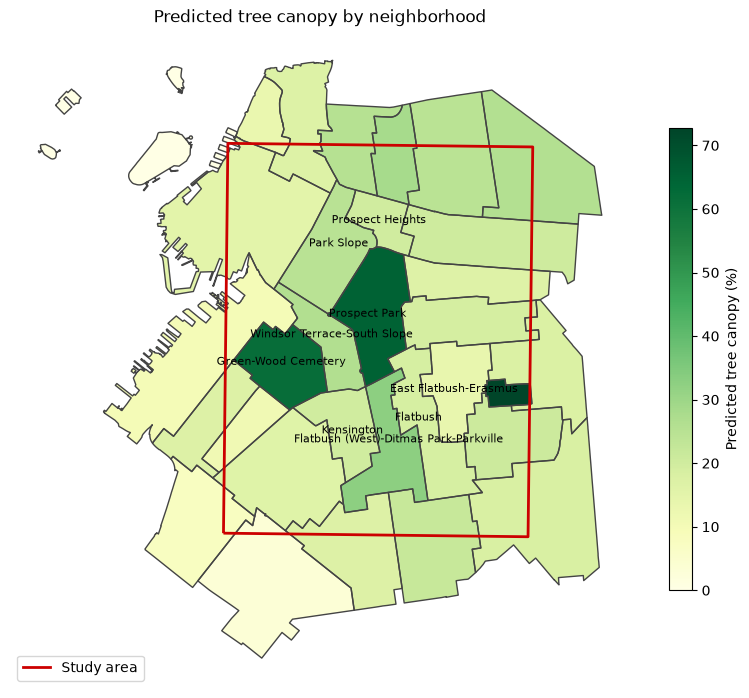

In [15]:
from matplotlib.lines import Line2D

figure, ax = plt.subplots(figsize=(10, 10))
web.plot(column="rf", cmap="YlGn", legend=True, ax=ax, legend_kwds={"label": "Predicted tree canopy (%)", "shrink": 0.6})
web.boundary.plot(ax=ax, color="#444444", linewidth=1)
# The study area outline; neighborhoods crossing it are only partly covered.
study_area.boundary.plot(ax=ax, color="#cc0000", linewidth=2)
# Labels are placed inside each shape, as representative_point stays within irregular outlines.
for _, n in web[web["fully_inside"]].iterrows():
    point = n.geometry.representative_point()
    ax.annotate(n[NAME], (point.x, point.y), ha="center", fontsize=8)
ax.legend(handles=[Line2D([0], [0], color="#cc0000", linewidth=2, label="Study area")], loc="lower left")
ax.set_axis_off(); ax.set_title("Predicted tree canopy by neighborhood")
plt.savefig(config.FIGURES / "05_choropleth.png", dpi=120, bbox_inches="tight"); plt.show()